# LED Characterization Data Processor

Processes raw voltage data from an ESP32 + MCP4725 DAC + LMP358P VCCS LED characterization system.

**Data files (pre-trimmed to 768 points = 256 steps × 3 readings):**
| File | Description | Unit |
|------|-------------|------|
| `256_MCP_Out.txt` | DAC output baseline (multimeter) | mV |
| `White_LED_Sense.txt` | Sense resistor voltage with white LED | mV |
| `Red_LED.txt` | Red LED forward voltage | V |
| `Blue_LED.txt` | Blue LED forward voltage | V |
| `White_LED.txt` | White LED forward voltage | V |
| `Yellow_LED.txt` | Yellow LED forward voltage | V |
| `Green_LED.txt` | Green LED forward voltage | V |

**Circuit:**
```
MCP4725 DAC → 10kΩ/2kΩ voltage divider → LMP358P op-amp (+input)
Op-amp output → 2N2222 → LED (from 9V) → R_sense (10Ω) → GND
R_sense voltage → op-amp (−input, feedback loop = VCCS)
```

Ideal full-scale: 3300 × (2k / 12k) = **550 mV** across R_sense  
256 DAC steps (codes 0–255), 3 readings per step → 768 raw data points per file

## 1. Setup

In [ ]:
import csv
import statistics
import os
import matplotlib.pyplot as plt
import numpy as np

# Plot styling
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

## 1a. Import Data from Google Drive

To import data from Google Drive, you'll need to mount your Drive and then copy the necessary files to the Colab environment.

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define the path to your data folder in Google Drive
DRIVE_DATA_FOLDER_NAME = 'LED data'

# Create a directory for the data in the Colab environment if it doesn't exist
!mkdir -p ./data

# Copy the base files and additional samples (2-5) for each color
colors = ['White', 'Red', 'Blue', 'Yellow', 'Green']

for color in colors:
    # Copy primary file (e.g., White_LED.txt)
    !cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/{color}_LED.txt" .

    # Copy samples 2 through 5
    for i in range(2, 6):
        !cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/{color}_LED_{i}.txt" .

# Special case for the baseline file
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/256_MCP_Out.txt" .
!cp -n "/content/drive/MyDrive/{DRIVE_DATA_FOLDER_NAME}/White_LED_Sense.txt" .

print('All available LED sample files copied from Google Drive.')

print('Data files copied from Google Drive.')

Mounted at /content/drive
All available LED sample files copied from Google Drive.
Data files copied from Google Drive.


In [ ]:
# ── Config ──

R_SENSE      = 10.0    # Sense resistor (Ω)
IDEAL_FS_MV  = 550.0   # Ideal voltage (mV)
NUM_STEPS    = 256     # DAC steps (codes 0–255)
STEP_SIZE_MV = IDEAL_FS_MV / (NUM_STEPS - 1)  # ~2.157 mV/step
READINGS_PER_STEP = 3  # Raw readings per DAC step

# File paths — update DATA_DIR to match your file locations
DATA_DIR = '.'

DAC_BASE_FILE = os.path.join(DATA_DIR, '256_MCP_Out.txt')
SENSE_FILE    = os.path.join(DATA_DIR, 'White_LED_Sense.txt')
LED_FILES     = {
    'red':    os.path.join(DATA_DIR, 'Red_LED.txt'),
    'blue':   os.path.join(DATA_DIR, 'Blue_LED.txt'),
    'white':  os.path.join(DATA_DIR, 'White_LED.txt'),
    'yellow': os.path.join(DATA_DIR, 'Yellow_LED.txt'),
    'green':  os.path.join(DATA_DIR, 'Green_LED.txt'),
}

# LED colors for plotting
LED_COLORS = {
    'red':    '#e24b4a',
    'yellow': '#d4a017',
    'green':  '#2ca02c',
    'blue':   '#3266ad',
    'white':  '#888780',
}

print(f'Step size: {STEP_SIZE_MV:.4f} mV/step')
print(f'Max current at full scale: {IDEAL_FS_MV / R_SENSE:.1f} mA')

Step size: 2.1569 mV/step
Max current at full scale: 55.0 mA


## 2. Parsing

In [ ]:
def read_raw_file(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    data_str = ','.join(lines[1:])
    values = []
    for token in data_str.split(','):
        token = token.strip()
        if token:
            try:
                values.append(float(token))
            except ValueError:
                pass
    return values


def group_by_transition(values, jump_threshold=1.5):
    if not values:
        return []

    steps = []
    group = [values[0]]

    for i in range(1, len(values)):
        if values[i] - group[0] > jump_threshold:
            steps.append(group)
            group = [values[i]]
        else:
            group.append(values[i])

    if group:
        steps.append(group)
    return steps


def group_by_triplet(values, n=3):
    return [values[i:i+n] for i in range(0, len(values) - n + 1, n)]


def steps_to_means(steps, max_n=NUM_STEPS):
    """Compute mean of each step group, return up to max_n values."""
    return [statistics.mean(g) for g in steps[:max_n]]


print('Parsing functions defined.')

Parsing functions defined.


## 3. DAC Baseline (Multimeter Reference)



In [ ]:
# Parse and process DAC baseline
raw_dac = read_raw_file(DAC_BASE_FILE)
print(f'Raw DAC data points: {len(raw_dac)}')

# Point after reset
reset_idx = raw_dac.index(0.0)
sweep_dac = raw_dac[reset_idx:]

# Group into steps by voltage transitions
dac_groups = group_by_transition(sweep_dac, jump_threshold=1.5)
dac_means  = steps_to_means(dac_groups)

# Calculate Error
n_dac      = len(dac_means)
dac_codes  = list(range(n_dac))
dac_ideal  = [i * STEP_SIZE_MV for i in dac_codes]
dac_error  = [dac_means[i] - dac_ideal[i] for i in range(n_dac)]

print(f'Steps detected: {n_dac}')
print(f'Output range:   {dac_means[0]:.2f} – {dac_means[-1]:.2f} mV')
print(f'Ideal range:    {dac_ideal[0]:.2f} – {dac_ideal[-1]:.2f} mV')
print(f'Gain error:     {(dac_means[-1] / IDEAL_FS_MV - 1) * 100:.2f}%')
print(f'Mean error:     {statistics.mean(dac_error):.2f} mV')
print(f'Error range:    {min(dac_error):.2f} to {max(dac_error):.2f} mV')

Raw DAC data points: 768
Steps detected: 256
Output range:   0.10 – 539.60 mV
Ideal range:    0.00 – 550.00 mV
Gain error:     -1.89%
Mean error:     -4.97 mV
Error range:    -10.68 to 1.09 mV


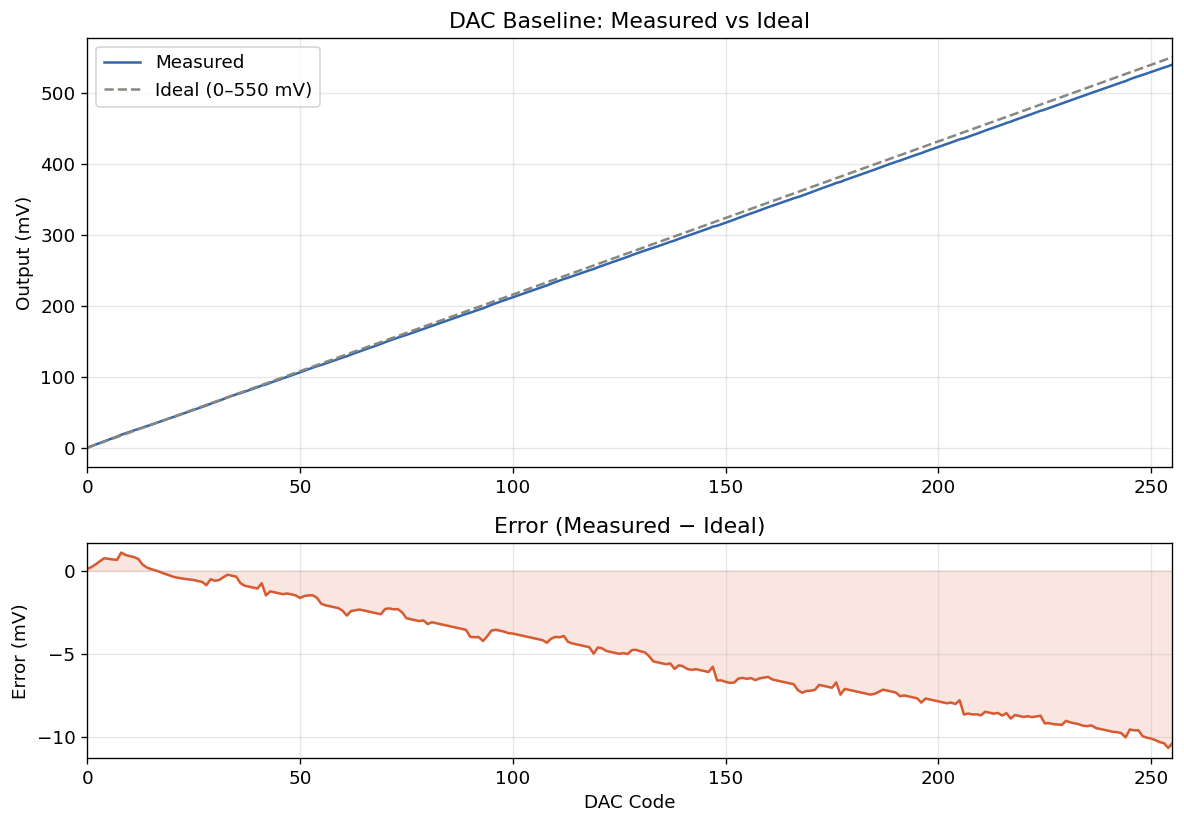

In [ ]:
# Plot DAC baseline: measured vs ideal + error
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[2, 1])

ax1.plot(dac_codes, dac_means, linewidth=1.5, label='Measured', color='#3266ad')
ax1.plot(dac_codes, dac_ideal, linewidth=1.5, label='Ideal (0–550 mV)',
         color='#888780', linestyle='--')
ax1.set_ylabel('Output (mV)')
ax1.set_title('DAC Baseline: Measured vs Ideal')
ax1.legend()
ax1.set_xlim(0, 255)

ax2.plot(dac_codes, dac_error, linewidth=1.5, color='#D85A30')
ax2.fill_between(dac_codes, dac_error, alpha=0.15, color='#D85A30')
ax2.set_xlabel('DAC Code')
ax2.set_ylabel('Error (mV)')
ax2.set_title('Error (Measured − Ideal)')
ax2.set_xlim(0, 255)

plt.tight_layout()
plt.savefig('dac_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Sense Resistor Voltage (VCCS Tracking)

The sense voltage is measured across the 10Ω resistor with a white LED in circuit.  
Comparing it to the DAC baseline shows the VCCS loop tracking error — dominated by the LMP358P input offset voltage (~1 mV).

In [ ]:
# Parse and process sense resistor data
raw_sense = read_raw_file(SENSE_FILE)
print(f'Raw sense data points: {len(raw_sense)}')

reset_idx_s = raw_sense.index(0.0)
sweep_sense = raw_sense[reset_idx_s:]

sense_groups = group_by_transition(sweep_sense, jump_threshold=1.5)
sense_means  = steps_to_means(sense_groups)

# Tracking error: sense − DAC baseline
n_cmp = min(len(dac_means), len(sense_means))
tracking_err = [sense_means[i] - dac_means[i] for i in range(n_cmp)]

print(f'Steps detected:    {len(sense_means)}')
print(f'Sense range:       {sense_means[0]:.2f} – {sense_means[-1]:.2f} mV')
print(f'Tracking error:')
print(f'  Mean:   {statistics.mean(tracking_err):+.2f} mV')
print(f'  Stdev:  {statistics.stdev(tracking_err):.2f} mV')
print(f'  Range:  {min(tracking_err):+.2f} to {max(tracking_err):+.2f} mV')

Raw sense data points: 768
Steps detected:    253
Sense range:       0.08 – 531.83 mV
Tracking error:
  Mean:   -1.12 mV
  Stdev:  0.34 mV
  Range:  -1.83 to +0.20 mV


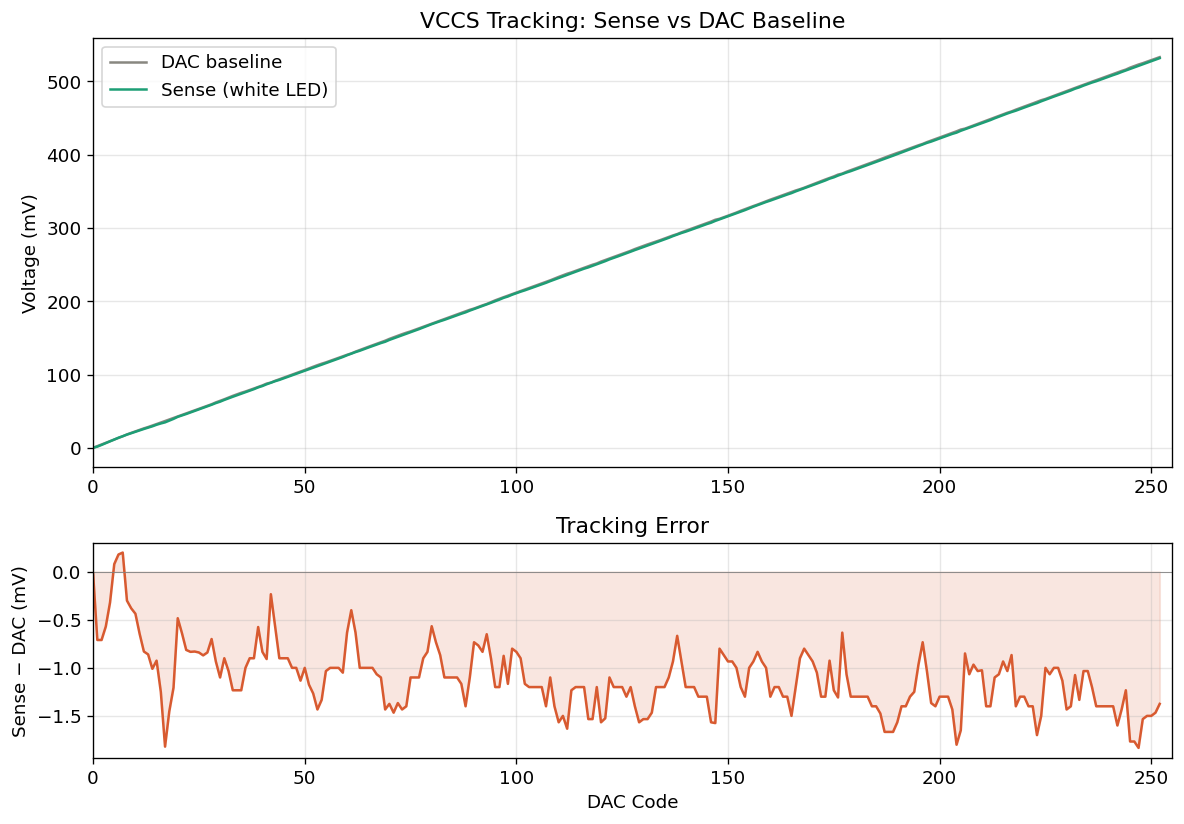

In [ ]:
# Plot sense vs DAC baseline + tracking error
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[2, 1])

ax1.plot(dac_codes[:n_cmp], dac_means[:n_cmp], linewidth=1.5,
         label='DAC baseline', color='#888780')
ax1.plot(dac_codes[:n_cmp], sense_means[:n_cmp], linewidth=1.5,
         label='Sense (white LED)', color='#1D9E75')
ax1.set_ylabel('Voltage (mV)')
ax1.set_title('VCCS Tracking: Sense vs DAC Baseline')
ax1.legend()
ax1.set_xlim(0, 255)

ax2.plot(dac_codes[:n_cmp], tracking_err, linewidth=1.5, color='#D85A30')
ax2.fill_between(dac_codes[:n_cmp], tracking_err, alpha=0.15, color='#D85A30')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_xlabel('DAC Code')
ax2.set_ylabel('Sense − DAC (mV)')
ax2.set_title('Tracking Error')
ax2.set_xlim(0, 255)

plt.tight_layout()
plt.savefig('vccs_tracking.png', dpi=150, bbox_inches='tight')
plt.show()

## 4b. Multimeter vs Sense Voltage — Cross-Validation

Both the DAC baseline and the sense resistor voltage were measured with the **ZOYI ZT-300AB multimeter**.  
The DAC baseline was captured without an LED in circuit; the sense voltage was captured with the white LED in circuit.  
Since the VCCS forces V_sense ≈ V_DAC, comparing these two independent measurements cross-validates the system.

In [ ]:
# Multimeter cross-validation: sense vs DAC baseline
mm_diff = [sense_means[i] - dac_means[i] for i in range(n_cmp)]

print(f'Compared steps:  {n_cmp}')
print(f'DAC range:       {dac_means[0]:.2f} – {dac_means[n_cmp-1]:.2f} mV')
print(f'Sense range:     {sense_means[0]:.2f} – {sense_means[n_cmp-1]:.2f} mV')
print(f'Difference (Sense − DAC):')
print(f'  Mean:   {statistics.mean(mm_diff):+.2f} mV')
print(f'  Stdev:  {statistics.stdev(mm_diff):.2f} mV')
print(f'  Range:  {min(mm_diff):+.2f} to {max(mm_diff):+.2f} mV')


Compared steps:  253
DAC range:       0.10 – 533.20 mV
Sense range:     0.08 – 531.83 mV
Difference (Sense − DAC):
  Mean:   -1.12 mV
  Stdev:  0.34 mV
  Range:  -1.83 to +0.20 mV


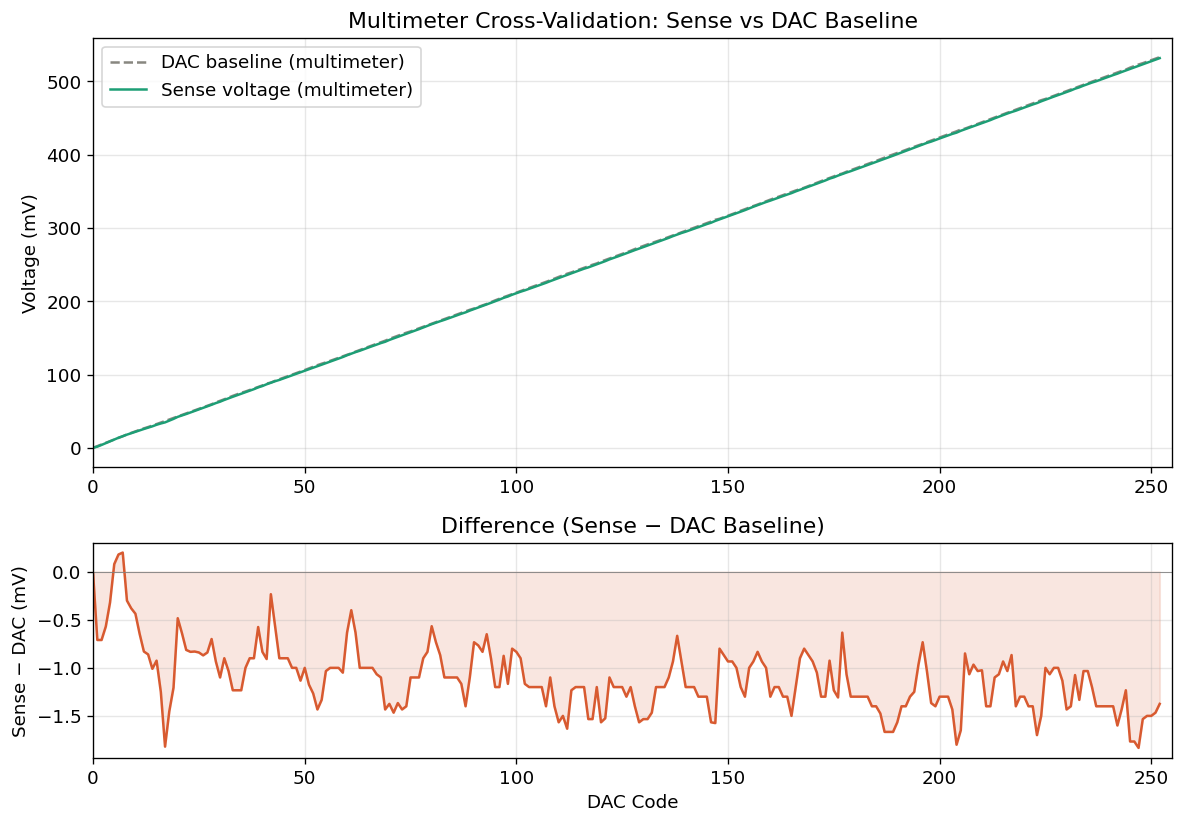

In [ ]:
# Plot multimeter sense vs DAC baseline + difference
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[2, 1])

ax1.plot(dac_codes[:n_cmp], dac_means[:n_cmp], linewidth=1.5,
         label='DAC baseline (multimeter)', color='#888780', linestyle='--')
ax1.plot(dac_codes[:n_cmp], sense_means[:n_cmp], linewidth=1.5,
         label='Sense voltage (multimeter)', color='#1D9E75')
ax1.set_ylabel('Voltage (mV)')
ax1.set_title('Multimeter Cross-Validation: Sense vs DAC Baseline')
ax1.legend()
ax1.set_xlim(0, 255)

ax2.plot(dac_codes[:n_cmp], mm_diff, linewidth=1.5, color='#D85A30')
ax2.fill_between(dac_codes[:n_cmp], mm_diff, alpha=0.15, color='#D85A30')
ax2.axhline(y=0, color='gray', linewidth=0.5)
ax2.set_xlabel('DAC Code')
ax2.set_ylabel('Sense − DAC (mV)')
ax2.set_title('Difference (Sense − DAC Baseline)')
ax2.set_xlim(0, 255)

plt.tight_layout()
plt.savefig('multimeter_vs_sense.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. LED Forward Voltage (V-I Characteristics)

Each LED Vf file (pre-trimmed to 768 points) has:
- A preamble (last few readings from previous state)
- A dip below 1.0 V (DAC reset)
- The Vf sweep starting above ~1.5 V

Current is computed from the sense resistor: `I_mA = V_sense / R_sense`

In [ ]:
def process_LED_vf(filepath, name, glitch_range=(1.5, 5.0)):
    """Process one LED Vf file.

    Returns dict with 'name', 'vf_V' (list of per-step means), 'n_steps'.
    glitch_range filters out obvious data corruption.
    """
    raw = read_raw_file(filepath)
    print(f'  [{name:6s}] Raw data points: {len(raw)}')

    # Find reset dip (first value < 1.0 V)
    reset_idx = None
    for i, v in enumerate(raw):
        if v < 1.0:
            reset_idx = i
            break

    if reset_idx is None:
        print(f'  [{name}] WARNING: no reset dip found')
        return {'name': name, 'vf_V': [], 'n_steps': 0}

    # Find sweep start (first value > 1.5 V after reset)
    start_idx = None
    for i in range(reset_idx, len(raw)):
        if raw[i] >= 1.5:
            start_idx = i
            break

    if start_idx is None:
        print(f'  [{name}] WARNING: no sweep start found')
        return {'name': name, 'vf_V': [], 'n_steps': 0}

    sweep = raw[start_idx:]

    # Filter glitches
    lo, hi = glitch_range
    sweep = [v for v in sweep if lo < v < hi]

    # Group into triplets and average
    steps = group_by_triplet(sweep, n=READINGS_PER_STEP)
    means = steps_to_means(steps)

    n = len(means)
    print(f'  [{name:6s}] {n} steps, Vf: {means[0]:.3f} – {means[-1]:.3f} V')
    return {'name': name, 'vf_V': means, 'n_steps': n}


print('LED processing function defined.')

LED processing function defined.


In [ ]:
# Process all LED files
print('Processing LED forward voltage data...\n')
led_data = {}
for color, fpath in LED_FILES.items():
    if os.path.exists(fpath):
        led_data[color] = process_LED_vf(fpath, color)
    else:
        print(f'  [{color}] File not found: {fpath}')
    print()

# Compute current from sense voltage
current_mA = [v / R_SENSE for v in sense_means]
print(f'Current array: {len(current_mA)} steps, range: {current_mA[0]:.2f} – {current_mA[-1]:.2f} mA')

Processing LED forward voltage data...

  [red   ] Raw data points: 768
  [red   ] 255 steps, Vf: 1.692 – 2.168 V

  [blue  ] Raw data points: 768
  [blue  ] 255 steps, Vf: 2.509 – 3.095 V

  [white ] Raw data points: 768
  [white ] 255 steps, Vf: 2.506 – 3.338 V

  [yellow] Raw data points: 768
  [yellow] 255 steps, Vf: 1.716 – 2.041 V

  [green ] Raw data points: 768
  [green ] 255 steps, Vf: 1.725 – 2.057 V

Current array: 253 steps, range: 0.01 – 53.18 mA


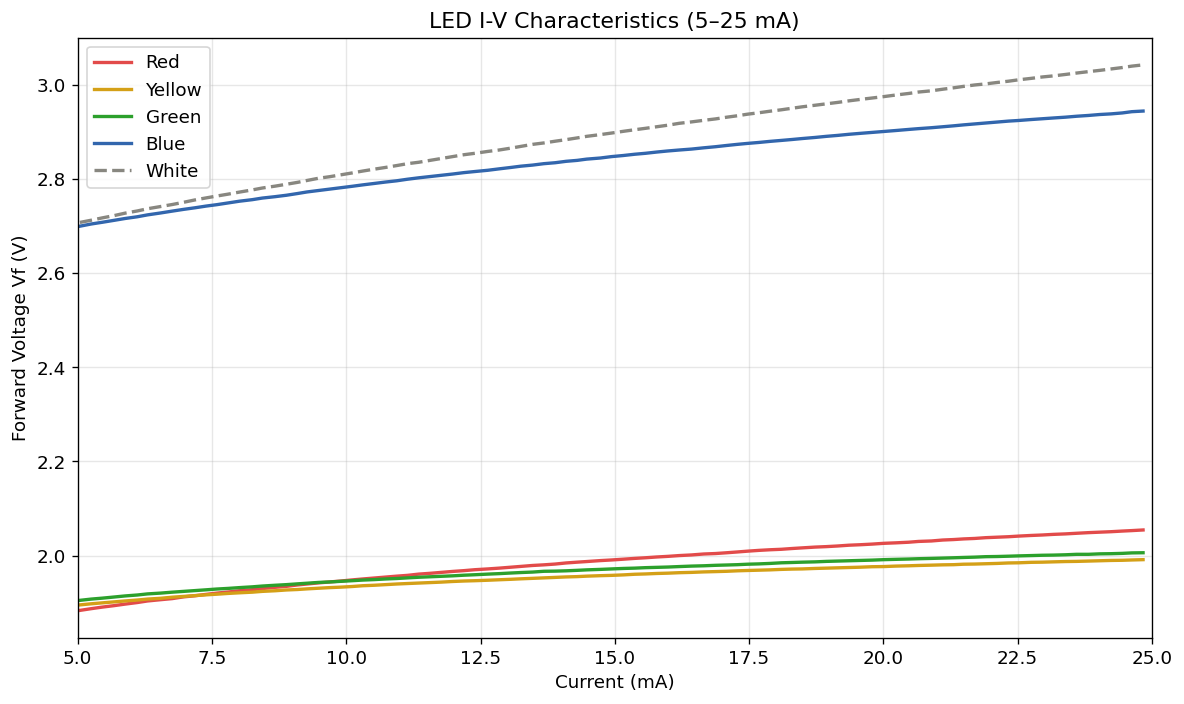

In [ ]:
# Plot LED I-V characteristics (5–25 mA range)
fig, ax = plt.subplots(figsize=(10, 6))

plot_order = ['red', 'yellow', 'green', 'blue', 'white']
linestyles = {'red': '-', 'yellow': '-', 'green': '-', 'blue': '-', 'white': '--'}

I_MIN, I_MAX = 5.0, 25.0   # mA — analysis window

for color in plot_order:
    ds = led_data.get(color)
    if ds is None or ds['n_steps'] == 0:
        continue

    n = min(len(current_mA), ds['n_steps'])
    I_arr = np.array(current_mA[:n])
    V_arr = np.array(ds['vf_V'][:n])
    mask = (I_arr >= I_MIN) & (I_arr <= I_MAX)

    ax.plot(I_arr[mask], V_arr[mask],
            linewidth=2, color=LED_COLORS[color],
            linestyle=linestyles[color], label=f"{color.capitalize()}")

ax.set_xlabel('Current (mA)')
ax.set_ylabel('Forward Voltage Vf (V)')
ax.set_title(f'LED I-V Characteristics ({I_MIN:.0f}–{I_MAX:.0f} mA)')
ax.set_xlim(I_MIN, I_MAX)
ax.legend()

plt.tight_layout()
plt.savefig('led_iv_characteristics.png', dpi=150, bbox_inches='tight')
plt.show()


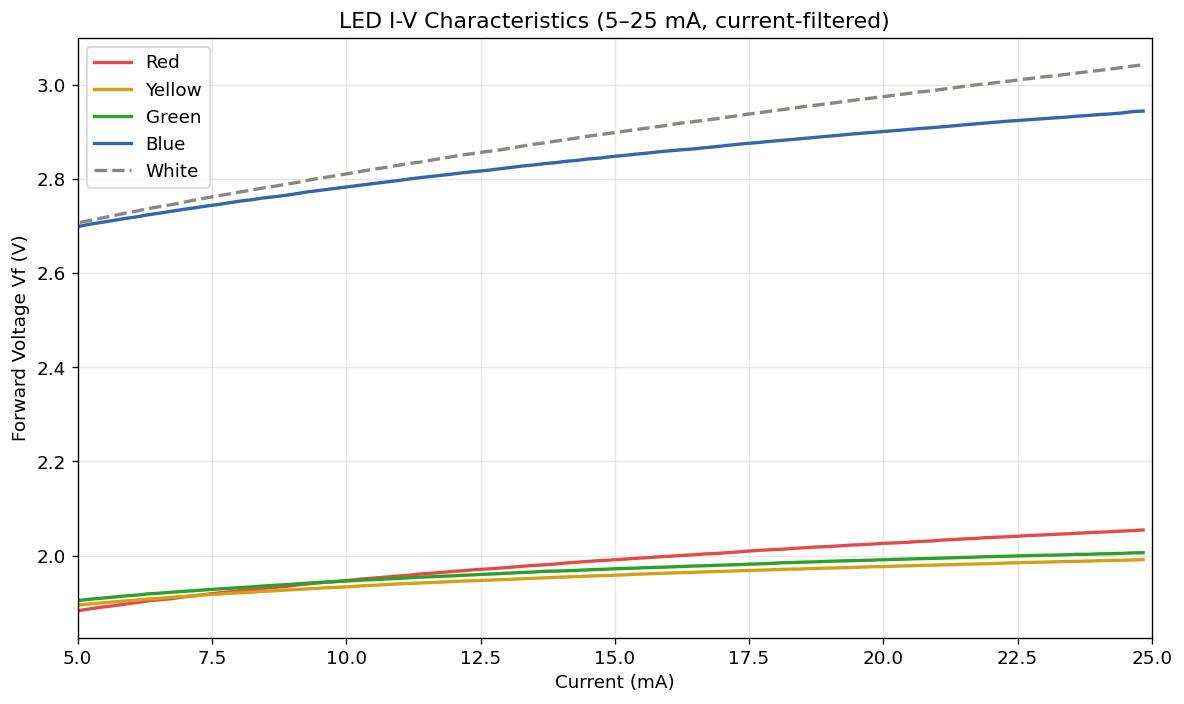

In [ ]:
# I-V plot — same 5–25 mA window, current-based filter
# (the old START_IDX transient-skip is subsumed by the 5 mA lower bound)
fig, ax = plt.subplots(figsize=(10, 6))

for color in plot_order:
    ds = led_data.get(color)
    if ds is None or ds['n_steps'] == 0:
        continue

    n = min(len(current_mA), ds['n_steps'])
    I_arr = np.array(current_mA[:n])
    V_arr = np.array(ds['vf_V'][:n])
    mask = (I_arr >= I_MIN) & (I_arr <= I_MAX)

    ax.plot(I_arr[mask], V_arr[mask],
            linewidth=2, color=LED_COLORS[color],
            linestyle=linestyles[color], label=f"{color.capitalize()}")

ax.set_xlabel('Current (mA)')
ax.set_ylabel('Forward Voltage Vf (V)')
ax.set_title(f'LED I-V Characteristics ({I_MIN:.0f}–{I_MAX:.0f} mA, current-filtered)')
ax.set_xlim(I_MIN, I_MAX)
ax.legend()

plt.tight_layout()
plt.savefig('led_iv_trimmed.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Summary: Vf at Standard Test Currents

In [ ]:
def find_nearest_idx(arr, target):
    """Index of element in arr closest to target."""
    return min(range(len(arr)), key=lambda i: abs(arr[i] - target))


test_currents = [10.0, 20.0, 50.0]

print(f'{"Color":<8}', end='')
for I in test_currents:
    print(f'  Vf@{I:.0f}mA', end='')
print(f'  Rd(20-50)  Steps')
print('─' * 62)

for color in ['red', 'yellow', 'green', 'blue', 'white']:
    ds = led_data.get(color)
    if ds is None or ds['n_steps'] == 0:
        continue

    print(f'{color:<8}', end='')
    vf_at = {}
    for I in test_currents:
        idx = find_nearest_idx(current_mA, I)
        if idx < ds['n_steps']:
            vf = ds['vf_V'][idx]
            vf_at[I] = vf
            print(f'  {vf:.3f} V', end='')
        else:
            print(f'     N/A ', end='')

    # Dynamic resistance
    if 20.0 in vf_at and 50.0 in vf_at:
        rd = (vf_at[50.0] - vf_at[20.0]) / (50.0 - 20.0) * 1000
        print(f'   {rd:5.1f} Ω', end='')
    else:
        print(f'     N/A', end='')

    print(f'    {ds["n_steps"]}')

Color     Vf@10mA  Vf@20mA  Vf@50mA  Rd(20-50)  Steps
──────────────────────────────────────────────────────────────
red       1.946 V  2.026 V  2.157 V     4.4 Ω    255
yellow    1.933 V  1.977 V  2.037 V     2.0 Ω    255
green     1.946 V  1.992 V  2.052 V     2.0 Ω    255
blue      2.781 V  2.900 V  3.080 V     6.0 Ω    255
white     2.808 V  2.974 V  3.307 V    11.1 Ω    255


## 7. Export to CSV

Three output files:
1. `dac_baseline.csv` — DAC code, ideal, measured, error, raw readings
2. `sense_vs_dac.csv` — DAC vs sense voltage comparison
3. `led_iv_characteristics.csv` — current + Vf for all LEDs

In [ ]:
# Export DAC baseline
with open('dac_baseline.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['dac_code', 'ideal_mV', 'measured_mV', 'error_mV',
                'num_readings', 'raw_readings'])
    for i in range(n_dac):
        raw_str = ';'.join(f'{v:.2f}' for v in dac_groups[i])
        w.writerow([i, f'{dac_ideal[i]:.3f}', f'{dac_means[i]:.3f}',
                    f'{dac_error[i]:.3f}', len(dac_groups[i]), raw_str])
print('Saved: dac_baseline.csv')

# Export sense vs DAC
with open('sense_vs_dac.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['dac_code', 'dac_base_mV', 'sense_mV', 'tracking_error_mV'])
    for i in range(n_cmp):
        w.writerow([i, f'{dac_means[i]:.2f}', f'{sense_means[i]:.2f}',
                    f'{tracking_err[i]:.2f}'])
print('Saved: sense_vs_dac.csv')

# Export LED I-V (all colors, limited to common length)
ordered = ['red', 'yellow', 'green', 'blue', 'white']
n_common = len(current_mA)
for c in ordered:
    ds = led_data.get(c)
    if ds and ds['n_steps'] > 0:
        n_common = min(n_common, ds['n_steps'])

with open('led_iv_characteristics.csv', 'w', newline='') as f:
    w = csv.writer(f)
    header = ['dac_code', 'current_mA']
    cols = []
    for c in ordered:
        ds = led_data.get(c)
        if ds and ds['n_steps'] >= n_common:
            header.append(f'{c}_Vf_V')
            cols.append(c)
    w.writerow(header)
    for i in range(n_common):
        row = [i, f'{current_mA[i]:.3f}']
        for c in cols:
            row.append(f'{led_data[c]["vf_V"][i]:.4f}')
        w.writerow(row)
print(f'Saved: led_iv_characteristics.csv ({n_common} rows, {cols})')

# Also export full-length version (all steps) excluding short datasets
n_full = len(current_mA)
full_cols = [c for c in ordered
             if c in led_data and led_data[c]['n_steps'] >= n_full]

if full_cols:
    with open('led_iv_full.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['dac_code', 'current_mA'] + [f'{c}_Vf_V' for c in full_cols])
        for i in range(n_full):
            row = [i, f'{current_mA[i]:.3f}']
            for c in full_cols:
                row.append(f'{led_data[c]["vf_V"][i]:.4f}')
            w.writerow(row)
    print(f'Saved: led_iv_full.csv ({n_full} rows, {full_cols})')

Saved: dac_baseline.csv
Saved: sense_vs_dac.csv
Saved: led_iv_characteristics.csv (253 rows, ['red', 'yellow', 'green', 'blue', 'white'])
Saved: led_iv_full.csv (253 rows, ['red', 'yellow', 'green', 'blue', 'white'])


## 8. SPICE Diode Model Extraction (5 samples × 5 colors)

Extract standard SPICE diode parameters from measured I-V data for use in LTSpice. The fit is repeated independently for **5 samples of each LED color** (25 fits total) so we can report mean ± standard-deviation per parameter and assess sample-to-sample manufacturing consistency.

**SPICE diode model:** `I = Is × (exp(V / (N×Vt)) − 1)` with series resistance Rs

At currents well above Is, the measured forward voltage can be written as:

`Vf = N×Vt×ln(I/Is) + I×Rs`

Rearranging: `Vf = a×ln(I) + b×I + c`

where `a = N×Vt`, `b = Rs`, `c = −N×Vt×ln(Is)`

This is a **multilinear regression** problem — no iterative solver needed.

*Note:* The downstream LTSpice export cell uses `spice_params` (singular), which is repopulated below from each color's **Sample 1** fit for backward compatibility. Full per-sample parameters live in `spice_params_multi[color][sample]`, and per-color mean/std in `summary_stats[color]`.

In [ ]:
def extract_spice_params(current_mA, vf_V, name,
                         fit_range_mA=(5.0, 25.0), Vt=25.85e-3):
    """Extract SPICE diode parameters (Is, N, Rs) from measured I-V data.

    Uses multilinear regression on the model:
      Vf = a*ln(I) + b*I + c
    where a = N*Vt, b = Rs, c = -N*Vt*ln(Is)

    Parameters
    ----------
    current_mA : list of float — measured current in mA
    vf_V       : list of float — measured forward voltage in V
    name       : str — LED color name
    fit_range_mA : tuple — (min, max) current range for fitting (default 5–25 mA)
    Vt         : float — thermal voltage (V), default 25.85 mV at 25°C

    Returns
    -------
    dict with keys: Is, N, Rs, name, fit_range, residual_mV
    """
    I_arr = np.array(current_mA) * 1e-3  # convert to A
    V_arr = np.array(vf_V)

    # Select fitting range
    lo, hi = fit_range_mA[0] * 1e-3, fit_range_mA[1] * 1e-3
    mask = (I_arr >= lo) & (I_arr <= hi)
    I_fit = I_arr[mask]
    V_fit = V_arr[mask]

    if len(I_fit) < 10:
        print(f'  [{name}] WARNING: only {len(I_fit)} points in fit range')
        return None

    # Build regression matrix: V = a*ln(I) + b*I + c
    A = np.column_stack([np.log(I_fit), I_fit, np.ones(len(I_fit))])
    result, residuals, rank, sv = np.linalg.lstsq(A, V_fit, rcond=None)
    a, b, c = result

    # Extract parameters
    N  = a / Vt
    Rs = max(b, 0.0)          # clamp to non-negative (physical constraint)
    Is = np.exp(-c / a)       # in A

    # Compute fit quality (using clamped Rs)
    V_pred = a * np.log(I_fit) + Rs * I_fit + c
    rms_err = np.sqrt(np.mean((V_fit - V_pred)**2)) * 1000  # mV

    # Model curve restricted to the fit range (no extrapolation)
    V_model_fit = a * np.log(I_fit) + Rs * I_fit + c

    return {
        'name': name,
        'Is': Is,
        'N': N,
        'Rs': Rs,
        'fit_range_mA': fit_range_mA,
        'rms_err_mV': rms_err,
        'n_fit_pts': len(I_fit),
        'I_model': I_fit * 1e3,    # mA for plotting (within fit range only)
        'V_model': V_model_fit,    # V for plotting (within fit range only)
    }


print('SPICE extraction function defined (default fit range: 5–25 mA).')


SPICE extraction function defined (default fit range: 5–25 mA).


In [ ]:
# Extract SPICE parameters for all LEDs × 5 samples (5–25 mA fit window)
import matplotlib.colors as mcolors

print('Extracting SPICE diode model parameters across 5 samples per color '
      '(fit range: 5–25 mA)...\n')

FIT_RANGE_MA   = (5.0, 25.0)
all_led_colors = ['Red', 'Yellow', 'Green', 'Blue', 'White']
sample_names   = ['Sample 1', 'Sample 2', 'Sample 3', 'Sample 4', 'Sample 5']

# Load all samples: led_data_multi[color_lower][sample_name] = process_LED_vf(...)
led_data_multi     = {}
spice_params_multi = {}

for color_name in all_led_colors:
    key = color_name.lower()
    led_data_multi[key]     = {}
    spice_params_multi[key] = {}

    sample_files = {
        'Sample 1': f'{color_name}_LED.txt',
        'Sample 2': f'{color_name}_LED_2.txt',
        'Sample 3': f'{color_name}_LED_3.txt',
        'Sample 4': f'{color_name}_LED_4.txt',
        'Sample 5': f'{color_name}_LED_5.txt',
    }

    print(f'--- {color_name} LED ---')
    for sname, fname in sample_files.items():
        fpath = os.path.join(DATA_DIR, fname)
        if not os.path.exists(fpath):
            print(f'  [{sname}] File not found: {fpath}')
            continue

        ds = process_LED_vf(fpath, f'{key}_{sname.lower().replace(" ", "")}')
        led_data_multi[key][sname] = ds
        if ds['n_steps'] == 0:
            continue

        n = min(len(current_mA), ds['n_steps'])
        params = extract_spice_params(current_mA[:n], ds['vf_V'][:n],
                                      f'{key} {sname}',
                                      fit_range_mA=FIT_RANGE_MA)
        if params:
            spice_params_multi[key][sname] = params
    print()

# Backward-compatibility: keep singular `spice_params` populated from Sample 1
# (so the LTSpice export cell below continues to work unchanged).
spice_params = {color: spice_params_multi[color]['Sample 1']
                for color in spice_params_multi
                if 'Sample 1' in spice_params_multi[color]}

# --- Summary table: per-sample rows + mean ± std per color ---
print('=' * 78)
print(f'{"LED":<8} {"Sample":<10} {"Is (A)":>12} {"N":>6} '
      f'{"Rs (ohm)":>10} {"RMS (mV)":>12}')
print('=' * 78)

summary_stats = {}
for key in ['red', 'yellow', 'green', 'blue', 'white']:
    sp_dict = spice_params_multi.get(key, {})
    if not sp_dict:
        continue

    Is_list, N_list, Rs_list, rms_list = [], [], [], []
    for sname in sample_names:
        sp = sp_dict.get(sname)
        if sp is None:
            continue
        Is_list.append(sp['Is'])
        N_list.append(sp['N'])
        Rs_list.append(sp['Rs'])
        rms_list.append(sp['rms_err_mV'])
        print(f'{key:<8} {sname:<10} {sp["Is"]:>12.3e} {sp["N"]:>6.2f} '
              f'{sp["Rs"]:>10.2f} {sp["rms_err_mV"]:>12.2f}')

    if Is_list:
        Is_arr  = np.array(Is_list)
        N_arr   = np.array(N_list)
        Rs_arr  = np.array(Rs_list)
        rms_arr = np.array(rms_list)
        # ddof=1 -> sample std-dev; ddof=0 when only 1 sample to avoid NaN
        ddof = 1 if len(Is_list) > 1 else 0
        summary_stats[key] = {
            'Is_mean':  Is_arr.mean(),  'Is_std':  Is_arr.std(ddof=ddof),
            'N_mean':   N_arr.mean(),   'N_std':   N_arr.std(ddof=ddof),
            'Rs_mean':  Rs_arr.mean(),  'Rs_std':  Rs_arr.std(ddof=ddof),
            'rms_mean': rms_arr.mean(), 'rms_std': rms_arr.std(ddof=ddof),
            'n_samples': len(Is_list),
        }
        print(f'{key:<8} {"mean":<10} {Is_arr.mean():>12.3e} {N_arr.mean():>6.2f} '
              f'{Rs_arr.mean():>10.2f} {rms_arr.mean():>12.2f}')
        print(f'{key:<8} {"std":<10} {Is_arr.std(ddof=ddof):>12.3e} '
              f'{N_arr.std(ddof=ddof):>6.2f} {Rs_arr.std(ddof=ddof):>10.2f} '
              f'{rms_arr.std(ddof=ddof):>12.2f}')
        print('-' * 78)


Extracting SPICE diode model parameters across 5 samples per color (fit range: 5–25 mA)...

--- Red LED ---
  [red_sample1] Raw data points: 768
  [red_sample1] 255 steps, Vf: 1.692 – 2.168 V
  [red_sample2] Raw data points: 768
  [red_sample2] 255 steps, Vf: 1.679 – 2.210 V
  [red_sample3] Raw data points: 768
  [red_sample3] 255 steps, Vf: 1.669 – 2.127 V
  [red_sample4] Raw data points: 768
  [red_sample4] 254 steps, Vf: 1.671 – 2.122 V
  [red_sample5] Raw data points: 768
  [red_sample5] 255 steps, Vf: 1.670 – 2.131 V

--- Yellow LED ---
  [yellow_sample1] Raw data points: 768
  [yellow_sample1] 255 steps, Vf: 1.716 – 2.041 V
  [yellow_sample2] Raw data points: 768
  [yellow_sample2] 255 steps, Vf: 1.725 – 2.062 V
  [yellow_sample3] Raw data points: 768
  [yellow_sample3] 255 steps, Vf: 1.726 – 2.024 V
  [yellow_sample4] Raw data points: 768
  [yellow_sample4] 255 steps, Vf: 1.722 – 2.042 V
  [yellow_sample5] Raw data points: 768
  [yellow_sample5] 255 steps, Vf: 1.723 – 2.035 V

-

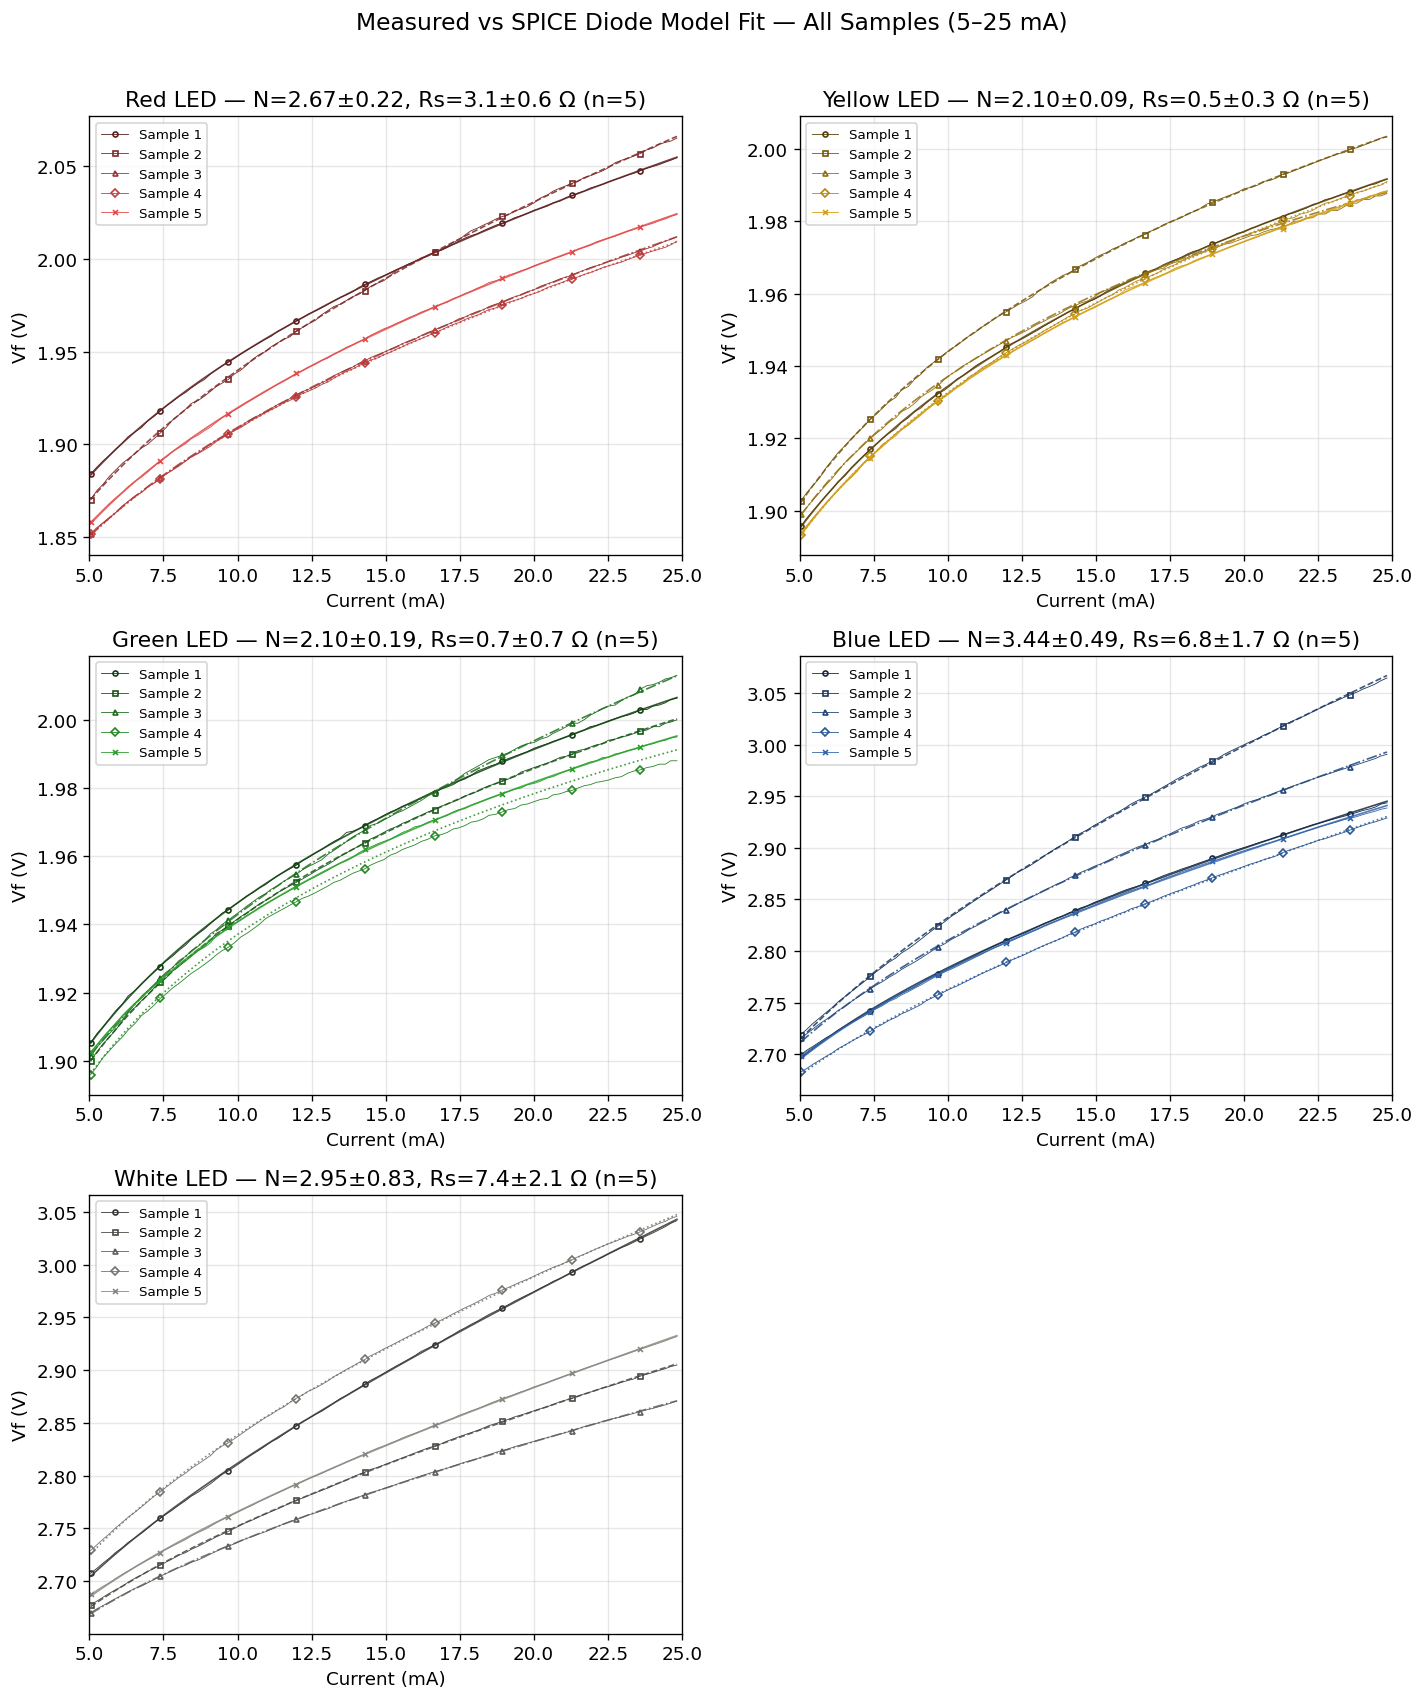

In [ ]:
sample_styles = {
    'Sample 1': {'linestyle': '-',  'marker': 'o'},
    'Sample 2': {'linestyle': '--', 'marker': 's'},
    'Sample 3': {'linestyle': '-.', 'marker': '^'},
    'Sample 4': {'linestyle': ':',  'marker': 'D'},
    'Sample 5': {'linestyle': '-',  'marker': 'x'},
}

def get_sample_shades(base_color, num_samples=5):
    """Light-to-dark shades of a base color, one per sample."""
    try:
        base_rgb = mcolors.to_rgb(base_color)
    except Exception:
        base_rgb = mcolors.to_rgb('black')
    shades = []
    for i in range(num_samples):
        factor = 0.4 + (i * 0.15)   # 40% -> 100% brightness
        shade  = tuple(min(1.0, c * factor) for c in base_rgb)
        shades.append(shade)
    return shades

# Change from 2x3 to 3x2
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for idx, color in enumerate(['red', 'yellow', 'green', 'blue', 'white']):
    ax     = axes[idx]
    shades = get_sample_shades(LED_COLORS.get(color, 'black'))

    sp_dict = spice_params_multi.get(color, {})
    ds_dict = led_data_multi.get(color, {})
    if not sp_dict:
        ax.set_visible(False)
        continue

    for s_idx, sname in enumerate(sample_names):
        sp = sp_dict.get(sname)
        ds = ds_dict.get(sname)
        if sp is None or ds is None:
            continue

        n      = min(len(current_mA), ds['n_steps'])
        I_meas = np.array(current_mA[:n])
        V_meas = np.array(ds['vf_V'][:n])
        lo, hi = sp['fit_range_mA']
        m      = (I_meas >= lo) & (I_meas <= hi)
        style  = sample_styles[sname]

        # Measured: thin line + sparse open markers
        ax.plot(I_meas[m], V_meas[m],
                linewidth=0.5, color=shades[s_idx],
                marker=style['marker'], markersize=3,
                markevery=max(1, int(m.sum() / 8)),
                markerfacecolor='none',
                label=f'{sname}')

        # SPICE model fit: dashed overlay in same shade
        ax.plot(sp['I_model'], sp['V_model'],
                linewidth=1.0, color=shades[s_idx],
                linestyle=style['linestyle'], alpha=0.85)

    stats = summary_stats.get(color)
    if stats:
        ax.set_title(f'{color.capitalize()} LED — '
                     f'N={stats["N_mean"]:.2f}±{stats["N_std"]:.2f}, '
                     f'Rs={stats["Rs_mean"]:.1f}±{stats["Rs_std"]:.1f} Ω '
                     f'(n={stats["n_samples"]})')
    else:
        ax.set_title(f'{color.capitalize()} LED')

    ax.set_xlabel('Current (mA)')
    ax.set_ylabel('Vf (V)')
    ax.set_xlim(FIT_RANGE_MA[0], FIT_RANGE_MA[1])
    ax.legend(fontsize=8, ncol=1, loc='best')

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('Measured vs SPICE Diode Model Fit — All Samples (5–25 mA)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('spice_model_fit_all_samples.png', dpi=150, bbox_inches='tight')
plt.show()

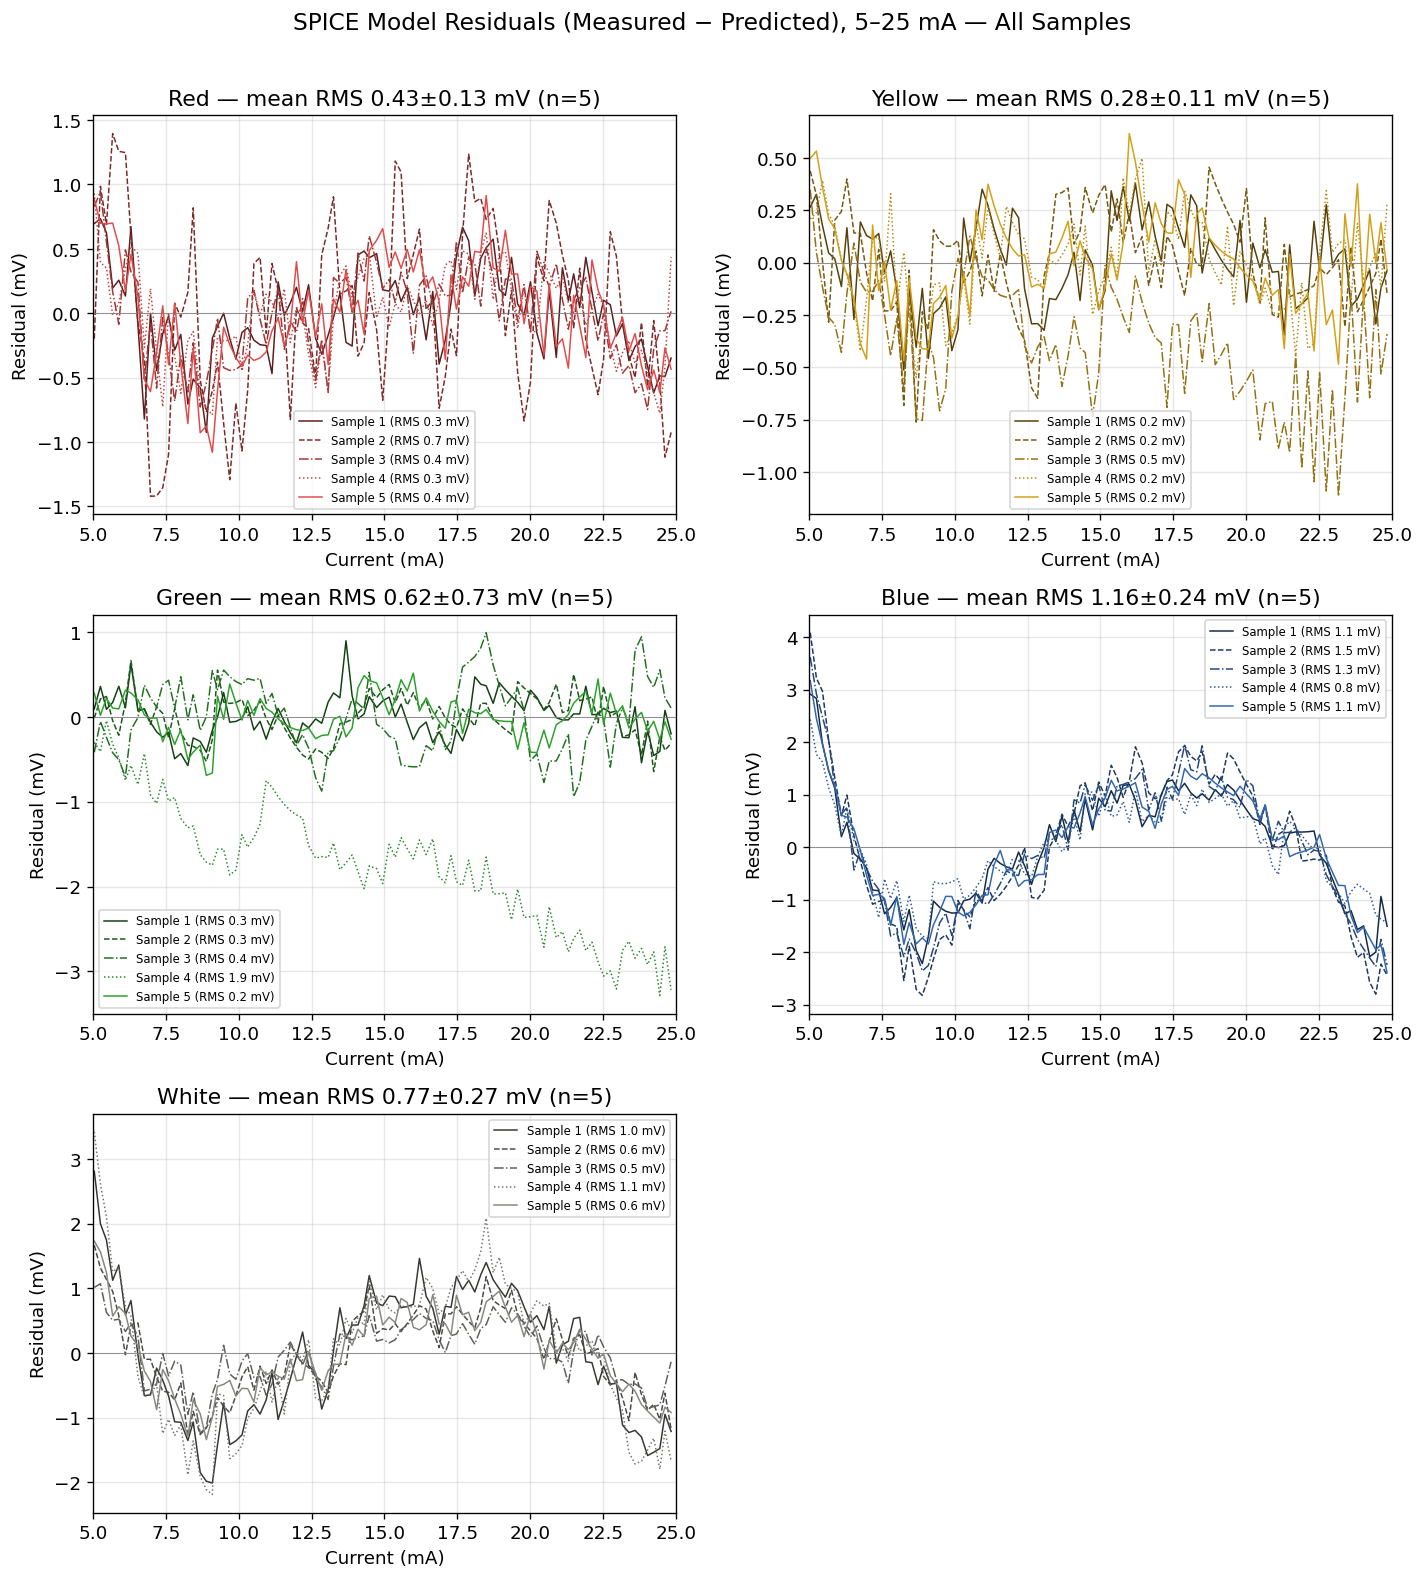

In [ ]:
# Residuals (measured − SPICE) for all LEDs × 5 samples, within 5–25 mA fit window
# Change from 2x3 to 3x2
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

Vt = 25.85e-3

for idx, color in enumerate(['red', 'yellow', 'green', 'blue', 'white']):
    ax     = axes[idx]
    shades = get_sample_shades(LED_COLORS.get(color, 'black'))

    sp_dict = spice_params_multi.get(color, {})
    ds_dict = led_data_multi.get(color, {})
    if not sp_dict:
        ax.set_visible(False)
        continue

    for s_idx, sname in enumerate(sample_names):
        sp = sp_dict.get(sname)
        ds = ds_dict.get(sname)
        if sp is None or ds is None:
            continue

        n      = min(len(current_mA), ds['n_steps'])
        I_meas = np.array(current_mA[:n])
        V_meas = np.array(ds['vf_V'][:n])
        lo, hi = sp['fit_range_mA']
        m      = (I_meas >= lo) & (I_meas <= hi)

        I_pos    = I_meas[m] * 1e-3   # A
        V_pos    = V_meas[m]
        V_pred   = sp['N'] * Vt * np.log(I_pos / sp['Is']) + I_pos * sp['Rs']
        residual = (V_pos - V_pred) * 1000  # mV

        style = sample_styles[sname]
        ax.plot(I_meas[m], residual,
                linewidth=0.9, color=shades[s_idx],
                linestyle=style['linestyle'],
                label=f'{sname} (RMS {sp["rms_err_mV"]:.1f} mV)')

    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.set_xlabel('Current (mA)')
    ax.set_ylabel('Residual (mV)')

    stats = summary_stats.get(color)
    if stats:
        ax.set_title(f'{color.capitalize()} — '
                     f'mean RMS {stats["rms_mean"]:.2f}±{stats["rms_std"]:.2f} mV '
                     f'(n={stats["n_samples"]})')
    else:
        ax.set_title(f'{color.capitalize()}')

    ax.set_xlim(FIT_RANGE_MA[0], FIT_RANGE_MA[1])
    ax.legend(fontsize=7, loc='best')

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle('SPICE Model Residuals (Measured − Predicted), 5–25 mA — All Samples',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('spice_residuals_all_samples.png', dpi=150, bbox_inches='tight')
plt.show()

Fitting SPICE model on averaged I-V curves (mean across 5 samples)...

LED            Is (A)      N   Rs (ohm)     RMS (mV)  n_samples
red         1.158e-14   2.67       3.08         0.34          5
yellow      3.389e-18   2.10       0.47         0.16          5
green       3.232e-18   2.10       0.66         0.15          5
blue        4.859e-16   3.44       6.76         1.14          5
white       3.644e-18   2.95       7.39         0.75          5

Comparison: fit-on-mean vs mean-of-per-sample-fits
LED      |      Is_avg  N_avg  Rs_avg  RMS_avg |     Is_mean N_mean Rs_mean  RMS_mean
--------------------------------------------------------------------------------------------
red      |    1.16e-14   2.67    3.08    0.34  |    3.01e-14   2.67    3.08     0.43
yellow   |    3.39e-18   2.10    0.47    0.16  |    6.27e-18   2.10    0.48     0.28
green    |    3.23e-18   2.10    0.66    0.15  |    1.97e-17   2.10    0.69     0.62
blue     |    4.86e-16   3.44    6.76    1.14  |    5.84e-1

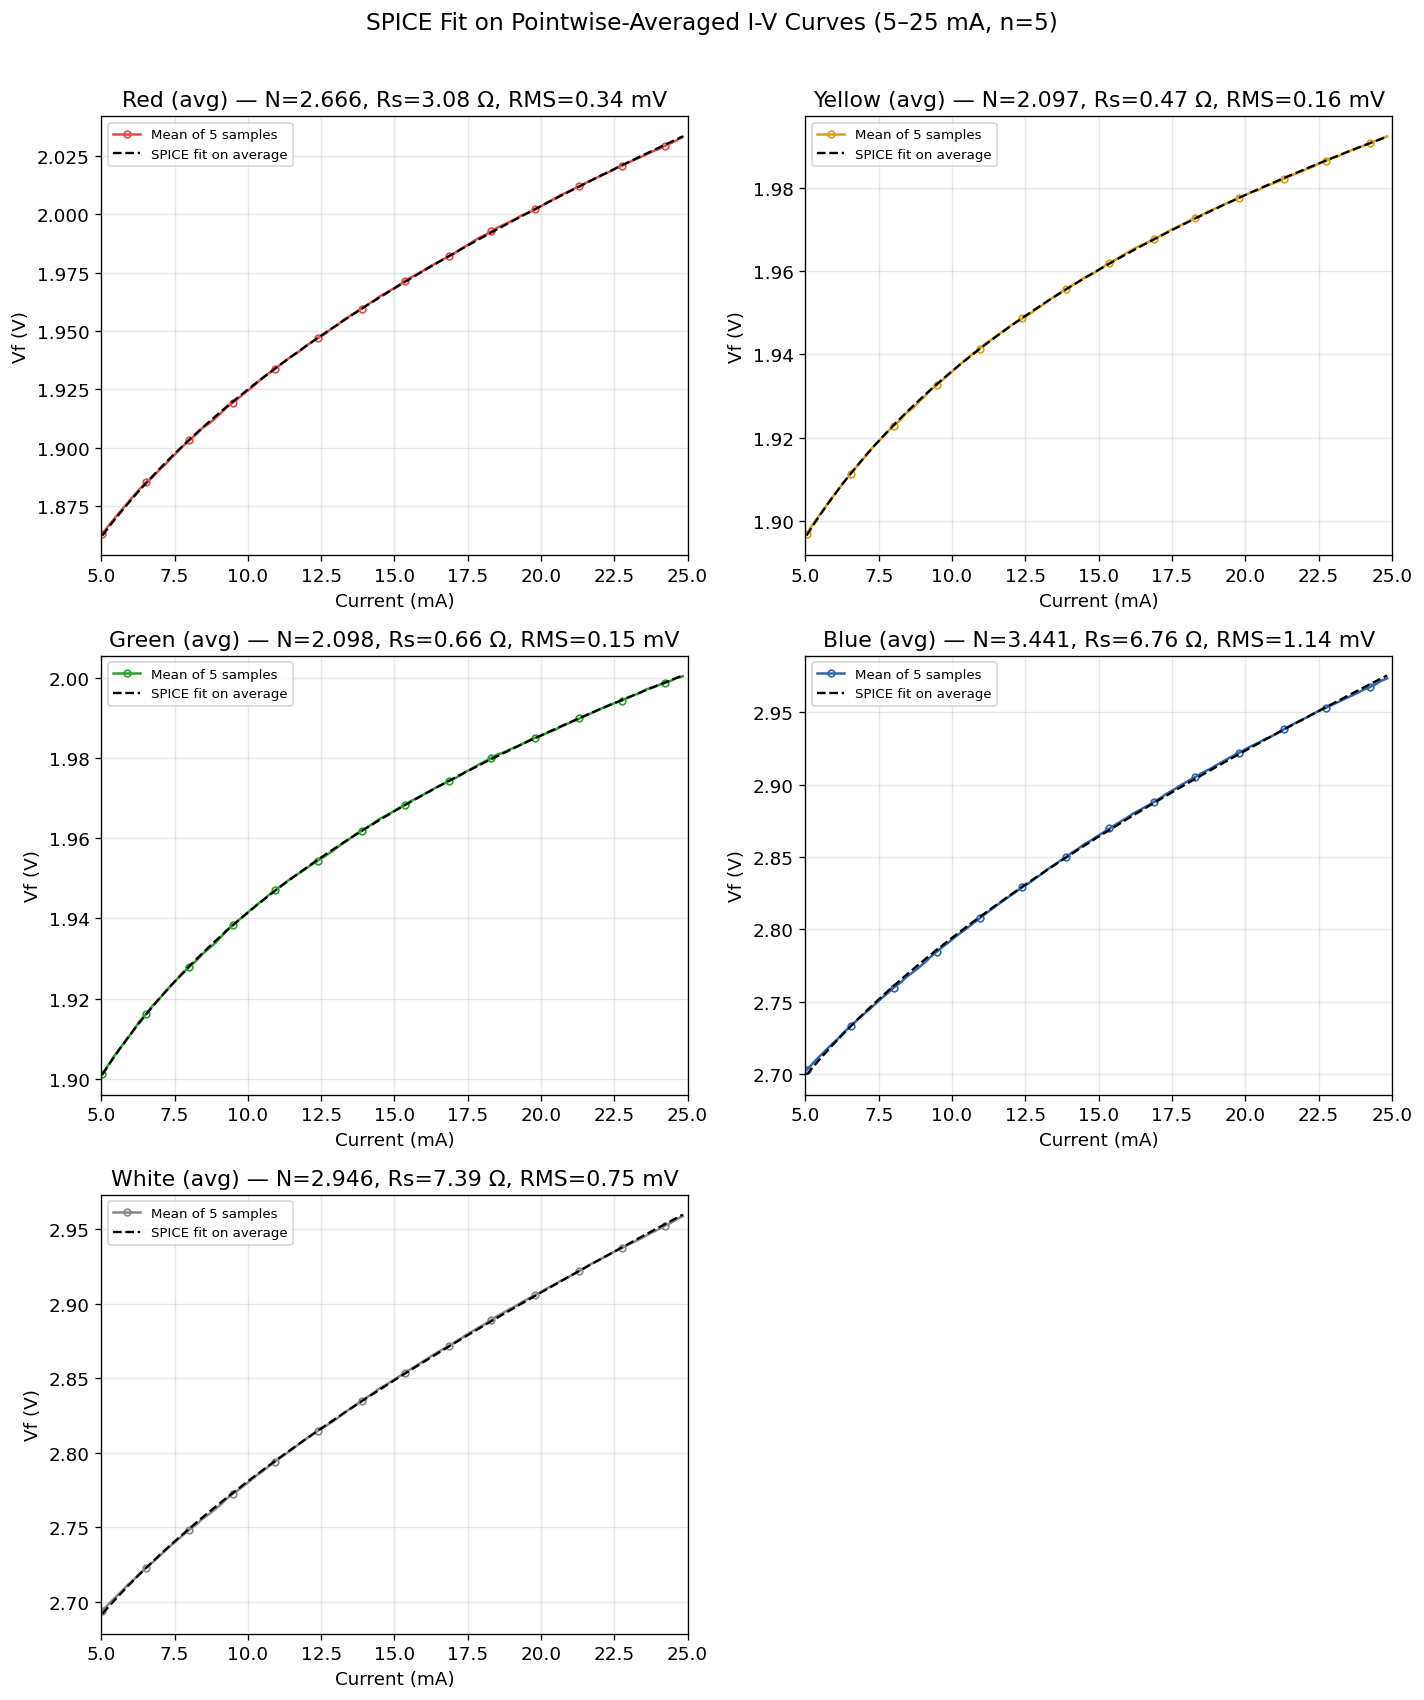

In [ ]:
# Fit SPICE on the *pointwise-averaged* I-V curve (one fit per color, n=5 samples)
# This is the "average-then-fit" path; the previous summary_stats was "fit-then-average".
print('Fitting SPICE model on averaged I-V curves (mean across 5 samples)...\n')
print(f'{"LED":<8} {"Is (A)":>12} {"N":>6} {"Rs (ohm)":>10} '
      f'{"RMS (mV)":>12} {"n_samples":>10}')
print('=' * 64)

spice_params_avg = {}
led_data_avg     = {}

for color in ['red', 'yellow', 'green', 'blue', 'white']:
    ds_dict = led_data_multi.get(color, {})
    if not ds_dict:
        continue

    # Stack per-sample Vf arrays (truncate to common length across samples & current)
    vf_lists = [ds['vf_V'] for ds in ds_dict.values() if ds['n_steps'] > 0]
    if not vf_lists:
        continue

    n_common = min(min(len(v) for v in vf_lists), len(current_mA))
    if n_common < 10:
        continue

    vf_stack = np.array([v[:n_common] for v in vf_lists])   # (n_samples, n_common)
    vf_avg   = vf_stack.mean(axis=0).tolist()

    led_data_avg[color] = {
        'name': color, 'vf_V': vf_avg,
        'n_steps': n_common, 'n_samples': vf_stack.shape[0],
    }

    params = extract_spice_params(current_mA[:n_common], vf_avg,
                                  f'{color}_avg', fit_range_mA=FIT_RANGE_MA)
    if params:
        spice_params_avg[color] = params
        print(f'{color:<8} {params["Is"]:>12.3e} {params["N"]:>6.2f} '
              f'{params["Rs"]:>10.2f} {params["rms_err_mV"]:>12.2f} '
              f'{vf_stack.shape[0]:>10d}')

# --- Side-by-side: fit-on-mean vs mean-of-per-sample-fits ---
print('\nComparison: fit-on-mean vs mean-of-per-sample-fits')
print(f'{"LED":<8} | {"Is_avg":>11} {"N_avg":>6} {"Rs_avg":>7} {"RMS_avg":>8} | '
      f'{"Is_mean":>11} {"N_mean":>6} {"Rs_mean":>7} {"RMS_mean":>9}')
print('-' * 92)
for color in ['red', 'yellow', 'green', 'blue', 'white']:
    a = spice_params_avg.get(color)
    s = summary_stats.get(color)
    if a is None or s is None:
        continue
    print(f'{color:<8} | {a["Is"]:>11.2e} {a["N"]:>6.2f} {a["Rs"]:>7.2f} '
          f'{a["rms_err_mV"]:>7.2f}  | '
          f'{s["Is_mean"]:>11.2e} {s["N_mean"]:>6.2f} {s["Rs_mean"]:>7.2f} '
          f'{s["rms_mean"]:>8.2f}')

# --- Plot: averaged measurement + SPICE fit on average ---
fig, axes = plt.subplots(3, 2, figsize=(12, 14))
axes = axes.flatten()

for idx, color in enumerate(['red', 'yellow', 'green', 'blue', 'white']):
    ax = axes[idx]
    ds = led_data_avg.get(color)
    sp = spice_params_avg.get(color)
    if ds is None or sp is None:
        ax.set_visible(False)
        continue

    n      = ds['n_steps']
    I_meas = np.array(current_mA[:n])
    V_meas = np.array(ds['vf_V'])
    lo, hi = sp['fit_range_mA']
    m      = (I_meas >= lo) & (I_meas <= hi)

    base = LED_COLORS.get(color, 'black')

    ax.plot(I_meas[m], V_meas[m],
            linewidth=1.5, color=base,
            marker='o', markersize=4, markerfacecolor='none',
            markevery=max(1, int(m.sum() / 12)),
            label=f'Mean of {ds["n_samples"]} samples')
    ax.plot(sp['I_model'], sp['V_model'],
            linewidth=1.4, color='black', linestyle='--',
            label='SPICE fit on average')

    ax.set_xlabel('Current (mA)')
    ax.set_ylabel('Vf (V)')
    ax.set_title(f'{color.capitalize()} (avg) — '
                 f'N={sp["N"]:.3f}, Rs={sp["Rs"]:.2f} Ω, '
                 f'RMS={sp["rms_err_mV"]:.2f} mV')
    ax.set_xlim(lo, hi)
    ax.legend(fontsize=8)

# Hide the unused 6th subplot
axes[5].set_visible(False)
plt.suptitle('SPICE Fit on Pointwise-Averaged I-V Curves (5–25 mA, n=5)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('spice_model_fit_averaged.png', dpi=150, bbox_inches='tight')
plt.show()

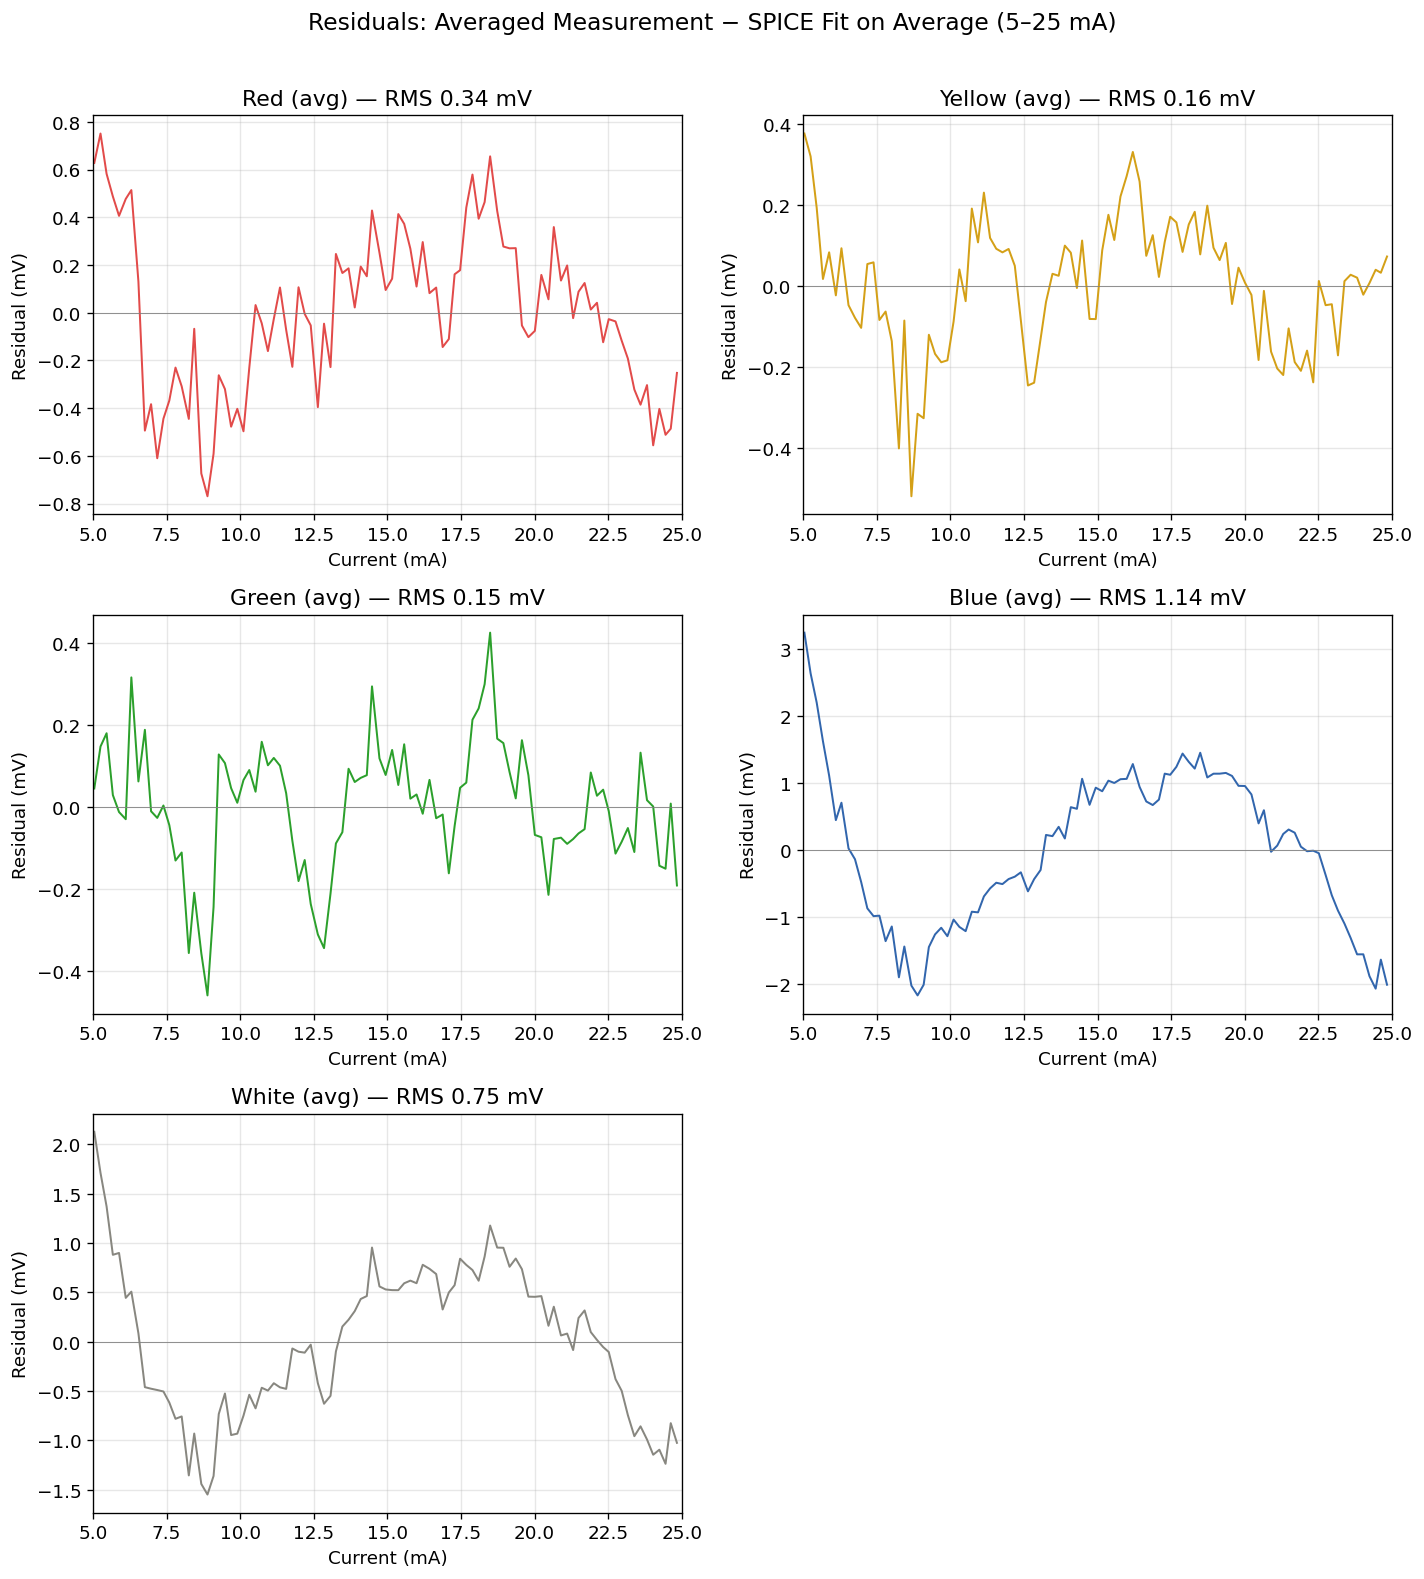

In [ ]:
# --- Residuals on the averaged curve (Averaged Measurement − SPICE Fit) ---
# Standard 3x2 grid layout
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
axes = axes.flatten()

Vt = 25.85e-3

for idx, color in enumerate(['red', 'yellow', 'green', 'blue', 'white']):
    ax = axes[idx]
    ds = led_data_avg.get(color)
    sp = spice_params_avg.get(color)
    if ds is None or sp is None:
        ax.set_visible(False)
        continue

    n      = ds['n_steps']
    I_meas = np.array(current_mA[:n])
    V_meas = np.array(ds['vf_V'])
    lo, hi = sp['fit_range_mA']
    m      = (I_meas >= lo) & (I_meas <= hi)

    I_pos    = I_meas[m] * 1e-3  # A
    V_pos    = V_meas[m]
    V_pred   = sp['N'] * Vt * np.log(I_pos / sp['Is']) + I_pos * sp['Rs']
    residual = (V_pos - V_pred) * 1000  # mV

    ax.plot(I_meas[m], residual,
            linewidth=1.2, color=LED_COLORS.get(color, 'black'))
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.set_xlabel('Current (mA)')
    ax.set_ylabel('Residual (mV)')
    ax.set_title(f'{color.capitalize()} (avg) — RMS {sp["rms_err_mV"]:.2f} mV')
    ax.set_xlim(lo, hi)

# Hide the unused 6th subplot
axes[5].set_visible(False)
plt.suptitle('Residuals: Averaged Measurement − SPICE Fit on Average (5–25 mA)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('spice_residuals_averaged.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. LTSpice Model Output

Generate `.model` statements and a `.lib` file ready to drop into LTSpice.

**Usage in LTSpice:**
1. Save the `.lib` file to your LTSpice library folder
2. Add `.include LED_measured.lib` to your schematic
3. Use the diode symbol and set the model name (e.g. `RED_LED`)

## 10. Averaged SPICE Model Output


In [ ]:
# Generate LTSpice .model statements from averaged data
print('=' * 75)
print('  LTSpice DIODE MODEL STATEMENTS (from Averaged Data)')
print('  Extracted from measured I-V data')
print('=' * 75)
print()

model_lines_avg = []
for color in ['red', 'yellow', 'green', 'blue', 'white']:
    sp_avg = spice_params_avg.get(color)
    if sp_avg is None:
        continue

    model_name_avg = f'{color.upper()}_LED_AVG'
    line_avg = (f'.model {model_name_avg} D('
                f'Is={sp_avg["Is"]:.4e} '
                f'N={sp_avg["N"]:.4f} '
                f'Rs={sp_avg["Rs"]:.4f})')
    model_lines_avg.append(line_avg)
    print(line_avg)

print()
print('-' * 75)

# Save as .lib file (averaged parameters)
lib_lines_avg = []
lib_lines_avg.append('* LED SPICE Models - Averaged from 5 samples')
lib_lines_avg.append('* System: ESP32 + MCP4725 DAC + LMP358P VCCS + 10 ohm sense')
lib_lines_avg.append('* Fitting range: 5-25 mA, T = 25 C')
lib_lines_avg.append('*')
lib_lines_avg.append('* Parameters: Is = saturation current')
lib_lines_avg.append('*             N  = ideality factor')
lib_lines_avg.append('*             Rs = series resistance')
lib_lines_avg.append('*')

for color in ['red', 'yellow', 'green', 'blue', 'white']:
    sp_avg = spice_params_avg.get(color)
    if sp_avg is None:
        continue
    model_name_avg = f'{color.upper()}_LED_AVG'
    lib_lines_avg.append(f'* {color.capitalize()} LED (avg): RMS fit error = {sp_avg["rms_err_mV"]:.2f} mV')
    lib_lines_avg.append(f'.model {model_name_avg} D(Is={sp_avg["Is"]:.4e} N={sp_avg["N"]:.4f} Rs={sp_avg["Rs"]:.4f})')
    lib_lines_avg.append('')

lib_text_avg = chr(10).join(lib_lines_avg)
with open('LED_averaged.lib', 'w') as f:
    f.write(lib_text_avg)
print('Saved: LED_averaged.lib')

# Also save parameter summary CSV (averaged parameters)
with open('spice_parameters_averaged.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['color', 'model_name', 'Is_A', 'N', 'Rs_ohm',
                'rms_err_mV', 'fit_range_lo_mA', 'fit_range_hi_mA', 'n_fit_pts', 'n_samples'])
    for color in ['red', 'yellow', 'green', 'blue', 'white']:
        sp_avg = spice_params_avg.get(color)
        ds_avg = led_data_avg.get(color)
        if sp_avg is None or ds_avg is None:
            continue
        w.writerow([color, f'{color.upper()}_LED_AVG',
                    f'{sp_avg["Is"]:.6e}', f'{sp_avg["N"]:.4f}', f'{sp_avg["Rs"]:.4f}',
                    f'{sp_avg["rms_err_mV"]:.2f}',
                    sp_avg['fit_range_mA'][0], sp_avg['fit_range_mA'][1],
                    sp_avg['n_fit_pts'], ds_avg['n_samples']])
print('Saved: spice_parameters_averaged.csv')


  LTSpice DIODE MODEL STATEMENTS (from Averaged Data)
  Extracted from measured I-V data

.model RED_LED_AVG D(Is=1.1584e-14 N=2.6660 Rs=3.0838)
.model YELLOW_LED_AVG D(Is=3.3890e-18 N=2.0974 Rs=0.4737)
.model GREEN_LED_AVG D(Is=3.2322e-18 N=2.0985 Rs=0.6633)
.model BLUE_LED_AVG D(Is=4.8587e-16 N=3.4408 Rs=6.7561)
.model WHITE_LED_AVG D(Is=3.6444e-18 N=2.9458 Rs=7.3947)

---------------------------------------------------------------------------
Saved: LED_averaged.lib
Saved: spice_parameters_averaged.csv
